In [1]:
# DAY 27 - BIAS VS VARIANCE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Prepare features and target

feature_columns = [
    "sales",
    "quantity",
    "discount",
    "shipping_cost",
    "shipping_days"
]

X = df[feature_columns].astype(float)

# Target: 1 = positive profit, 0 = zero/negative profit
y = (df["profit"] > 0).astype(int)

print("Features prepared successfully!")

print("\nFeatures:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features prepared successfully!

Features:
['sales', 'quantity', 'discount', 'shipping_cost', 'shipping_days']

X shape: (51290, 5)
y shape: (51290,)

Target distribution:
profit
1    38079
0    13211
Name: count, dtype: int64


In [4]:
# Split data into training and validation sets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training-validation split completed!")

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training-validation split completed!
Training data: (41032, 5)
Validation data: (10258, 5)


In [5]:
# Compare Decision Tree models with different complexity levels

depths = [1, 2, 3, 5, 10, 15, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    valid_accuracy = accuracy_score(
        y_valid,
        valid_pred
    )

    results.append({
        "Max Depth": str(depth),
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": valid_accuracy
    })

bias_variance_results = pd.DataFrame(results)

bias_variance_results[
    ["Training Accuracy", "Validation Accuracy"]
] = bias_variance_results[
    ["Training Accuracy", "Validation Accuracy"]
].round(3)

print("Bias-Variance comparison completed!")
print(bias_variance_results)

Bias-Variance comparison completed!
  Max Depth  Training Accuracy  Validation Accuracy
0         1              0.920                0.920
1         2              0.920                0.920
2         3              0.920                0.920
3         5              0.921                0.920
4        10              0.928                0.914
5        15              0.943                0.905
6      None              1.000                0.871


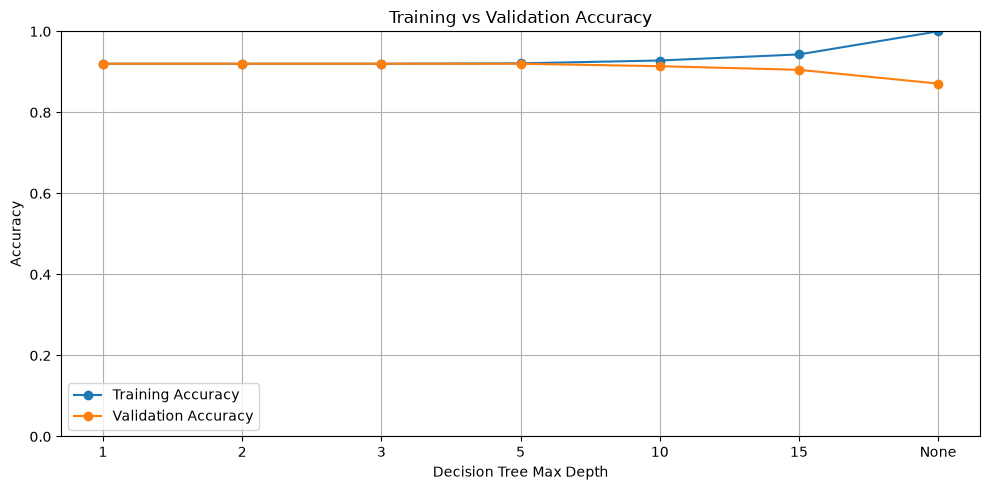

In [6]:
# Visualize training vs validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    bias_variance_results["Max Depth"],
    bias_variance_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    bias_variance_results["Max Depth"],
    bias_variance_results["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [7]:
# Calculate the training-validation accuracy gap

bias_variance_results["Accuracy Gap"] = (
    bias_variance_results["Training Accuracy"]
    - bias_variance_results["Validation Accuracy"]
)

bias_variance_results["Accuracy Gap"] = (
    bias_variance_results["Accuracy Gap"].round(3)
)

print("Training-validation gaps:")
print(
    bias_variance_results[
        [
            "Max Depth",
            "Training Accuracy",
            "Validation Accuracy",
            "Accuracy Gap"
        ]
    ]
)

Training-validation gaps:
  Max Depth  Training Accuracy  Validation Accuracy  Accuracy Gap
0         1              0.920                0.920         0.000
1         2              0.920                0.920         0.000
2         3              0.920                0.920         0.000
3         5              0.921                0.920         0.001
4        10              0.928                0.914         0.014
5        15              0.943                0.905         0.038
6      None              1.000                0.871         0.129


In [8]:
# Create a learning curve for the Decision Tree

learning_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

train_sizes, train_scores, validation_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print("Learning curve created successfully!")
print("\nTraining scores:")
print(train_mean.round(3))

print("\nValidation scores:")
print(validation_mean.round(3))

Learning curve created successfully!

Training scores:
[0.933 0.921 0.921 0.921 0.921]

Validation scores:
[0.918 0.919 0.919 0.92  0.919]


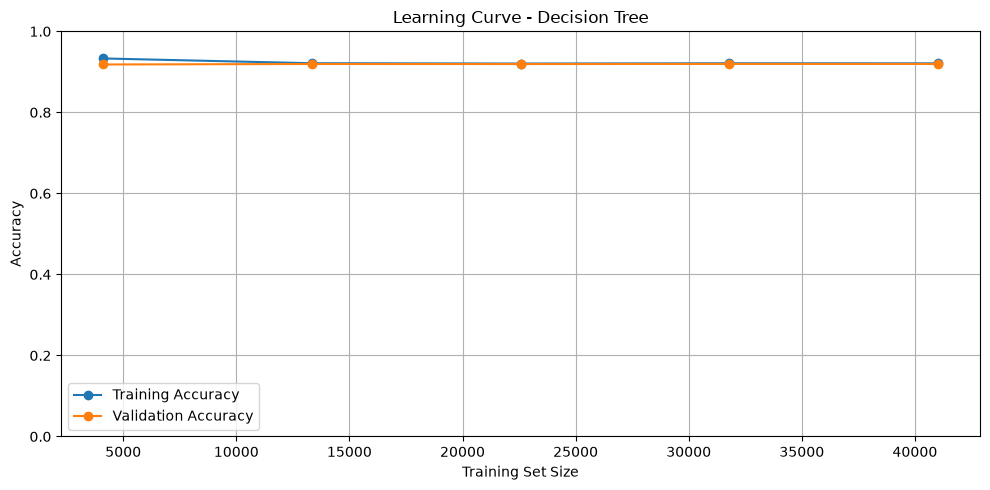

In [9]:
# Visualize the learning curve

plt.figure(figsize=(10, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Learning Curve - Decision Tree")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

In [10]:
# Save the bias-variance analysis report

bias_variance_results.to_csv(
    "bias_variance_analysis.csv",
    index=False
)

print("Bias-Variance analysis saved successfully!")
print("File: bias_variance_analysis.csv")

Bias-Variance analysis saved successfully!
File: bias_variance_analysis.csv


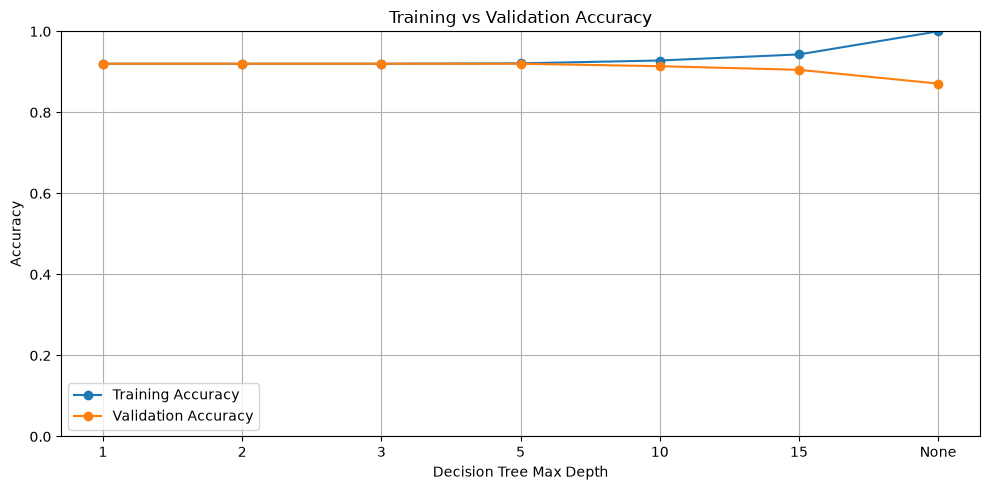

Bias-Variance graph saved successfully!
File: bias_variance_accuracy.png


In [11]:
# Save the training vs validation accuracy graph

plt.figure(figsize=(10, 5))

plt.plot(
    bias_variance_results["Max Depth"],
    bias_variance_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    bias_variance_results["Max Depth"],
    bias_variance_results["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "bias_variance_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bias-Variance graph saved successfully!")
print("File: bias_variance_accuracy.png")

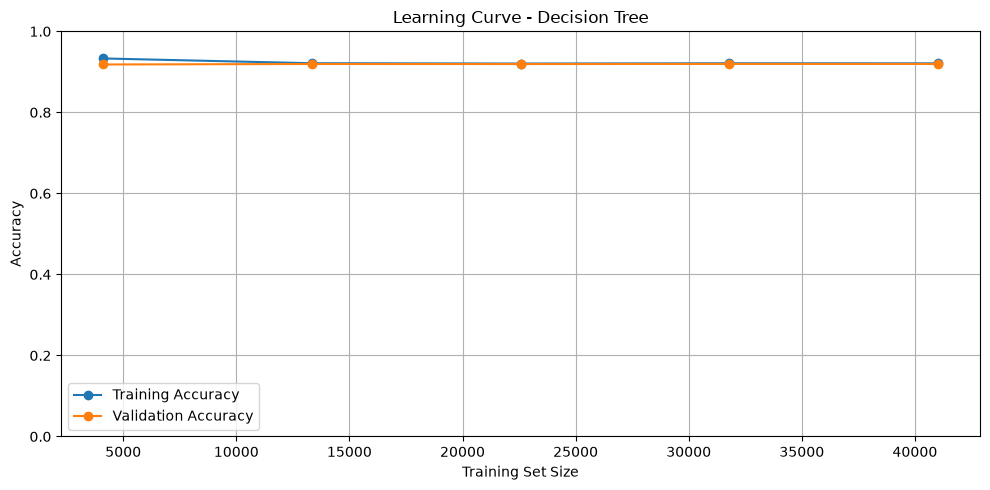

Learning curve saved successfully!
File: learning_curve.png


In [12]:
# Save the learning curve visualization

plt.figure(figsize=(10, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Learning Curve - Decision Tree")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Learning curve saved successfully!")
print("File: learning_curve.png")

In [13]:
# Final Day 27 Bias-Variance Summary

best_validation_index = bias_variance_results[
    "Validation Accuracy"
].idxmax()

best_depth = bias_variance_results.loc[
    best_validation_index,
    "Max Depth"
]

best_validation_accuracy = bias_variance_results.loc[
    best_validation_index,
    "Validation Accuracy"
]

smallest_gap_index = bias_variance_results[
    "Accuracy Gap"
].abs().idxmin()

smallest_gap_depth = bias_variance_results.loc[
    smallest_gap_index,
    "Max Depth"
]

smallest_gap = bias_variance_results.loc[
    smallest_gap_index,
    "Accuracy Gap"
]

print("==============================================")
print(" DAY 27 - BIAS VS VARIANCE SUMMARY")
print("==============================================")

print("\nBest Validation Accuracy:")
print("Max Depth:", best_depth)
print("Validation Accuracy:", best_validation_accuracy)

print("\nSmallest Training-Validation Gap:")
print("Max Depth:", smallest_gap_depth)
print("Accuracy Gap:", smallest_gap)

print("\nModel Complexity Results:")
print(
    bias_variance_results[
        [
            "Max Depth",
            "Training Accuracy",
            "Validation Accuracy",
            "Accuracy Gap"
        ]
    ]
)

print("\n==============================================")
print(" Bias-Variance analysis completed!")
print("==============================================")

 DAY 27 - BIAS VS VARIANCE SUMMARY

Best Validation Accuracy:
Max Depth: 1
Validation Accuracy: 0.92

Smallest Training-Validation Gap:
Max Depth: 1
Accuracy Gap: 0.0

Model Complexity Results:
  Max Depth  Training Accuracy  Validation Accuracy  Accuracy Gap
0         1              0.920                0.920         0.000
1         2              0.920                0.920         0.000
2         3              0.920                0.920         0.000
3         5              0.921                0.920         0.001
4        10              0.928                0.914         0.014
5        15              0.943                0.905         0.038
6      None              1.000                0.871         0.129

 Bias-Variance analysis completed!


In [14]:
# Final Day 27 file check

import os

files = [
    "bias_variance_analysis.csv",
    "bias_variance_accuracy.png",
    "learning_curve.png"
]

print("Day 27 files:")

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file)

Day 27 files:
✅ bias_variance_analysis.csv
✅ bias_variance_accuracy.png
✅ learning_curve.png
